# Stacking Ensemble

Purpose: combine predictions from multiple base learners into a
meta-learner.

In [ ]:

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

from pathlib import Path
PROJECT = Path('/content/drive/MyDrive/MSC THESIS')
DATA_DIR = PROJECT / 'ml_dataset' / 'data' / 'model_ready' / 'movie_success_v6'
RUN_DIR = DATA_DIR / 'colab_runs_v3'
RUN_DIR.mkdir(parents=True, exist_ok=True)
print('Data dir:', DATA_DIR)
print('Run dir: ', RUN_DIR)

Mounted at /content/drive
Data dir: /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6
Run dir:  /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v3


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    LeaveOneOut, KFold, StratifiedKFold, GridSearchCV,
    cross_val_predict, train_test_split, cross_val_score,
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
)
from scipy.stats import spearmanr, pearsonr

pd.set_option('display.max_columns', 80)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
print('Imports OK')

Imports OK


## 2 · Load + prepare data

In [ ]:

real_mov  = pd.read_csv(DATA_DIR / 'movie_features_v6.csv')
syn_mov   = pd.read_csv(DATA_DIR / 'movie_features_v6_synthetic.csv')
real_meta = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6.csv')
syn_meta  = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6_synthetic.csv')

LEAKAGE = ['budget_usd', 'revenue_usd', 'roi_percent', 'success_class',
           'imdb_rating', 'wom_multiplier', 'wom_multiplier_log']
real_mov = real_mov.drop(columns=LEAKAGE, errors='ignore')
syn_mov  = syn_mov.drop(columns=LEAKAGE, errors='ignore')

META_KEEP = [
    'movie_id', 'targeted_emotion', 'clip_duration_s',
    'cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
    'silence_ratio', 'music_presence', 'dialogue_density',
    'face_screen_time_ratio', 'lead_screen_time_ratio',
    'release_year', 'genre_primary', 'genre_secondary',
    'country_of_origin', 'budget_categorical',
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
]
real_meta_sub = real_meta[[c for c in META_KEEP if c in real_meta.columns]]
syn_meta_sub  = syn_meta[[c for c in META_KEEP if c in syn_meta.columns]]
real_mov = real_mov.merge(real_meta_sub, on='movie_id', how='left'); real_mov['is_synthetic'] = 0
syn_mov  = syn_mov.merge(syn_meta_sub, on='movie_id', how='left'); syn_mov['is_synthetic'] = 1
df_all = pd.concat([real_mov, syn_mov], ignore_index=True)
print(f'Combined: {len(df_all)} movies × {len(df_all.columns)} cols')

Combined: 50 movies × 343 cols


In [ ]:

DROP = {'movie_id', 'condition', 'n_participants',
        'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
        'is_synthetic'}
df_feat = df_all.copy()

ORD_MAP = {'low': 1, 'moderate': 2, 'high': 3}
ORD_COLS = ['cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
            'silence_ratio', 'music_presence', 'dialogue_density',
            'face_screen_time_ratio', 'lead_screen_time_ratio',
            'budget_categorical']
for c in ORD_COLS:
    if c in df_feat.columns: df_feat[c] = df_feat[c].map(ORD_MAP)

OH_COLS = ['targeted_emotion', 'genre_primary', 'genre_secondary', 'country_of_origin']
OH_COLS = [c for c in OH_COLS if c in df_feat.columns]
df_feat = pd.get_dummies(df_feat, columns=OH_COLS, prefix_sep='_',
                         dummy_na=False, dtype=int)

feature_cols = [c for c in df_feat.columns if c not in DROP]
X_all = df_feat[feature_cols].apply(pd.to_numeric, errors='coerce')
y_imdb_all = df_feat['imdb_rating'].astype(float)
y_wom_all  = df_feat['wom_multiplier_log'].astype(float)
synth_mask_all = df_feat['is_synthetic'].values.astype(bool)

X_all = X_all.drop(columns=X_all.columns[X_all.isna().all()].tolist())
X_all = X_all.drop(columns=X_all.columns[X_all.std() == 0].tolist())
feature_cols = list(X_all.columns)
print(f'Final feature matrix: {X_all.shape}')

Final feature matrix: (50, 360)


# Building the stacking ensemble

In [ ]:
from sklearn.ensemble import (
    StackingRegressor, RandomForestRegressor, HistGradientBoostingRegressor
)
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.cross_decomposition import PLSRegression

def make_stacking():
    base = [
        ('ridge',  Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', Ridge(alpha=100.0, random_state=42)),
        ])),
        ('enet',   Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', ElasticNet(alpha=1.0, l1_ratio=0.05,
                                  max_iter=10000, random_state=42)),
        ])),
        ('rf',     Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', RandomForestRegressor(n_estimators=500, max_depth=7,
                                              max_features=0.3,
                                              random_state=42, n_jobs=-1)),
        ])),
        ('gbm',    Pipeline([
            ('model', HistGradientBoostingRegressor(
                learning_rate=0.05, max_iter=200, max_depth=3,
                l2_regularization=1.0, random_state=42)),
        ])),
        ('pls',    Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', PLSRegression(n_components=2, scale=False)),
        ])),
    ]
    return StackingRegressor(
        estimators=base,
        final_estimator=Ridge(alpha=1.0, random_state=42),
        cv=5,        # internal CV for out-of-fold base predictions
        n_jobs=-1,
        passthrough=False,
    )

# Train/test split (80/20)

In [ ]:
# 80/20 random split (regression target — can't stratify on continuous,
# but with seed=42 it's reproducible)
X_train, X_test, yi_train, yi_test = train_test_split(
    X_all, y_imdb_all, test_size=0.2, random_state=42)
_,        _,        yw_train, yw_test = train_test_split(
    X_all, y_wom_all,  test_size=0.2, random_state=42)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 40, Test: 10


# Fit and evaluate stacking on IMDb

In [ ]:
def regression_metrics(y_true, y_pred):
    return {
        'r2':       r2_score(y_true, y_pred),
        'mae':      mean_absolute_error(y_true, y_pred),
        'rmse':     np.sqrt(mean_squared_error(y_true, y_pred)),
        'spearman': spearmanr(y_true, y_pred).correlation,
        'pearson':  pearsonr(y_true, y_pred)[0],
    }

stack_imdb = make_stacking()
stack_imdb.fit(X_train, yi_train)
y_pred_train_imdb = stack_imdb.predict(X_train)
y_pred_test_imdb  = stack_imdb.predict(X_test)

m_train_imdb = regression_metrics(yi_train, y_pred_train_imdb)
m_test_imdb  = regression_metrics(yi_test,  y_pred_test_imdb)
print('IMDb prediction:')
print(f'  Train: R²={m_train_imdb["r2"]:.3f}, ρ={m_train_imdb["spearman"]:.3f}')
print(f'  Test : R²={m_test_imdb["r2"]:.3f},  ρ={m_test_imdb["spearman"]:.3f}, MAE={m_test_imdb["mae"]:.3f}')

IMDb prediction:
  Train: R²=0.873, ρ=0.983
  Test : R²=0.631,  ρ=0.742, MAE=0.262


# Fit and evaluate stacking on WOM

In [ ]:
stack_wom = make_stacking()
stack_wom.fit(X_train, yw_train)
y_pred_train_wom = stack_wom.predict(X_train)
y_pred_test_wom  = stack_wom.predict(X_test)

m_train_wom = regression_metrics(yw_train, y_pred_train_wom)
m_test_wom  = regression_metrics(yw_test,  y_pred_test_wom)
print('WOM-log prediction:')
print(f'  Train: R²={m_train_wom["r2"]:.3f}, ρ={m_train_wom["spearman"]:.3f}')
print(f'  Test : R²={m_test_wom["r2"]:.3f},  ρ={m_test_wom["spearman"]:.3f}, MAE={m_test_wom["mae"]:.3f}')

WOM-log prediction:
  Train: R²=0.719, ρ=0.981
  Test : R²=0.018,  ρ=0.079, MAE=0.438


# Final-estimator coefficients (which base learners contributed)

In [ ]:
# The Ridge meta-learner coefficients tells which base learner contributed
# most to the stacked prediction.
base_names = ['ridge', 'enet', 'rf', 'gbm', 'pls']

print('Meta-learner coefficients (relative weight of each base learner):\n')
print(f'{"base":>6s}  {"IMDb":>10s}  {"WOM":>10s}')
print('─' * 35)
for i, name in enumerate(base_names):
    print(f'  {name:>4s}  {stack_imdb.final_estimator_.coef_[i]:>10.3f}  '
          f'{stack_wom.final_estimator_.coef_[i]:>10.3f}')

print(f'\nMeta intercept: IMDb={stack_imdb.final_estimator_.intercept_:.3f}, '
      f'WOM={stack_wom.final_estimator_.intercept_:.3f}')

Meta-learner coefficients (relative weight of each base learner):

  base        IMDb         WOM
───────────────────────────────────
  ridge       0.027       0.547
  enet       0.055      -0.103
    rf       0.777       0.365
   gbm      -0.088      -0.185
   pls       0.079      -0.030

Meta intercept: IMDb=1.142, WOM=0.690


# Visualisation

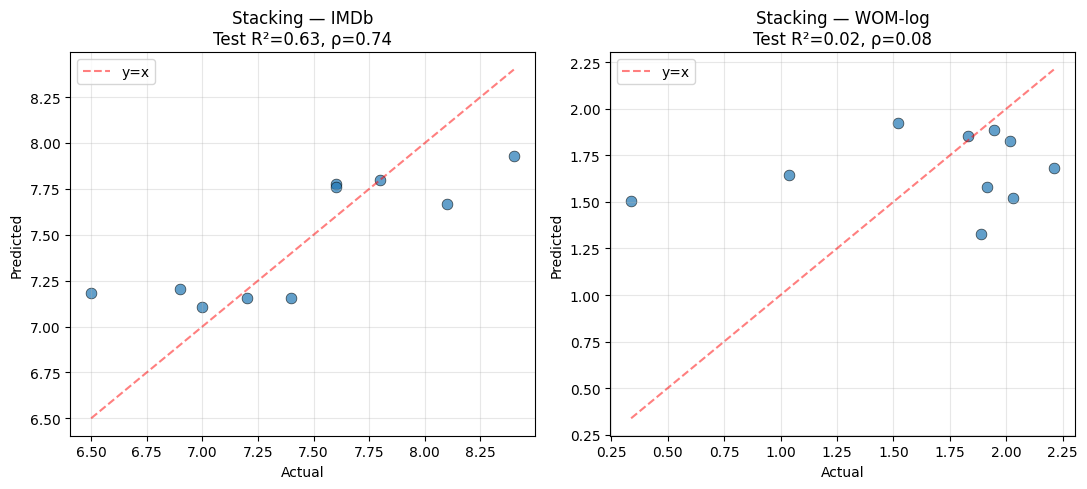

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (y_t, y_p, m, label) in zip(
        axes,
        [(yi_test, y_pred_test_imdb, m_test_imdb, 'IMDb'),
         (yw_test, y_pred_test_wom,  m_test_wom,  'WOM-log')]):
    ax.scatter(y_t, y_p, alpha=0.7, s=60, edgecolor='k', linewidth=0.5)
    lo, hi = min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())
    ax.plot([lo, hi], [lo, hi], 'r--', alpha=0.5, label='y=x')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(f'Stacking — {label}\nTest R²={m["r2"]:.2f}, ρ={m["spearman"]:.2f}')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
out = {
    'task': 'stacking_regression_train_test',
    'train_size': len(X_train),
    'test_size': len(X_test),
    'feature_count': len(feature_cols),
    'imdb': {
        'train': m_train_imdb,
        'test':  m_test_imdb,
        'meta_coefs': dict(zip(base_names,
                               stack_imdb.final_estimator_.coef_.tolist())),
        'meta_intercept': float(stack_imdb.final_estimator_.intercept_),
    },
    'wom': {
        'train': m_train_wom,
        'test':  m_test_wom,
        'meta_coefs': dict(zip(base_names,
                               stack_wom.final_estimator_.coef_.tolist())),
        'meta_intercept': float(stack_wom.final_estimator_.intercept_),
    },
}
out_path = RUN_DIR / 'results_stacking.json'
with open(out_path, 'w') as f: json.dump(out, f, indent=2, default=str)
print(f'Saved → {out_path}')

Saved → /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v3/results_stacking.json
